In [196]:
import sys
sys.path.append("..")
import importlib
import src.assay_calibration.data_utils.dataset
importlib.reload(src.assay_calibration.data_utils.dataset)
from src.assay_calibration.data_utils.dataset import Scoreset
import pandas as pd
import numpy as np
import pickle
logging.getLogger('matplotlib').setLevel(logging.ERROR)

import logging
import matplotlib.pyplot as plt
import seaborn as sns

In [208]:
csv_path = "/data/ross/assay_calibration/dataframe/integrated_variant_effect_dataset.tsv.gz"
print(f"Loading CSV from {csv_path}...")
df = pd.read_csv(csv_path, sep='\t')
print(f"Loaded {len(df)} total rows")

Loading CSV from /data/ross/assay_calibration/dataframe/integrated_variant_effect_dataset.tsv.gz...


/tmp/ipykernel_139538/1621325573.py:3: DtypeWarning: Columns (5,12,13,23,24,25,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,52,55,65,66,67,68,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, sep='\t')


Loaded 1079133 total rows


In [226]:
# df.loc[df["Dataset"] == "TSC2_IGVF", "Dataset"] = "TSC2_combined_unpublished"

# df.to_csv(csv_path, sep="\t", index=False, compression="gzip")
# df.to_csv('/data/ross/assay_calibration/scoresets_12_01_25/final_pillar_data_with_clinvar_18_25_gnomad_wREVEL_wAM_wspliceAI_wMutpred2_wtrainvar_expanded_111225.csv', index=False)

In [44]:
scoreset = Scoreset(df[df["Dataset"] == "BRCA1_Findlay_2018"])

In [7]:
[d for d in scoreset.samples]

[(array([0.85644614, 0.67938659, 0.86771364, 0.98276383, 0.80807763,
         0.50610954, 1.04311955, 0.87342674, 0.84711324, 0.85407583,
         0.81221012, 0.57235917]),
  'Pathogenic/Likely Pathogenic'),
 (array([ 1.09627663,  0.66580614,  1.13102526,  0.93521449,  0.69110279,
          1.00289409,  0.98855539,  1.25112948, -0.15698211,  1.08472727,
          0.80912739,  0.94624411,  1.02872791,  1.07821298,  0.86687154,
          1.05893787,  1.00013962,  0.89934332,  0.92293856,  0.90673005,
          0.99074439,  0.85649075,  0.90666039,  0.01876274,  0.94651679,
          1.11754924,  0.98727273,  1.03754092,  0.88532297]),
  'population'),
 (array([1.04201745, 1.08418477, 0.98053573, 1.06212995, 1.09695161,
         0.99225238, 1.12218843, 0.98293031, 1.00480439, 1.01874975,
         0.9316657 , 0.91323743, 1.01489246, 1.03581104, 0.91170682,
         1.05178804, 0.87438243, 0.93390197, 1.01350482, 0.99136051,
         0.79096572, 0.9406488 , 1.00586747, 1.03859687, 0.9641044

In [73]:
sample_names = [d[1] for d in scoreset.samples]
sample_names, scoreset.scores, scoreset.sample_assignments

(['Pathogenic/Likely Pathogenic',
  'Benign/Likely Benign',
  'population',
  'Synonymous'],
 array([-0.18754636, -0.01393005, -0.03821965, ..., -0.10121464,
         0.11534469, -4.00493657]),
 array([[False, False, False,  True],
        [False, False, False,  True],
        [False, False, False,  True],
        ...,
        [False,  True, False, False],
        [False,  True, False, False],
        [ True, False, False, False]]))

In [37]:
train_indices = np.full_like(scoreset.scores, False, dtype=bool)
train_indices[0] = True

In [38]:
train_indices

array([ True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [31]:
len(scoreset.scores), len(scoreset.sample_assignments[:,2]), len(train_indices)

(171, 171, 171)

In [41]:
scoreset.scores[scoreset.sample_assignments[:,0] & train_indices]

array([], dtype=float64)

In [45]:
((scoreset.sample_assignments == True).sum(axis=1) > 1).sum()

202

In [84]:
import gzip
import json

results_name = 'replicate_run_datasets_results_1000bootstraps_100fits'
with gzip.open(f'/data/ross/assay_calibration/{results_name}.json.gz', 'rt', encoding='utf-8') as f:
    results = json.load(f)
    
dataset_to_splits = load_splits_dict()

In [144]:
dataset = "BRCA1_Findlay_2018"
fits = results[dataset]
scoreset = Scoreset(df[df["Dataset"] == dataset])
n_c = "3c"

yang_dist = compute_bootstrap_yang_distances_parallel(dataset, n_c, fits, scoreset, dataset_to_splits, n_jobs=-1)

# Statistics
for sample, dists in yang_dist.items():
    valid = dists[~np.isnan(dists)]
    print(f"{sample}: mean={np.mean(valid):.4f} ± {np.std(valid):.4f}")

TypeError: list indices must be integers or slices, not str

In [242]:
datasets_to_exclude = ["TP53_Fayer_2021_meta", "TP53_Fayer_2021_meta_clinvar_2018", "SFPQ_unpublished", "F9_Popp_2025_model", "TSC2_rapgap_unpublished", "TSC2_tuberin_unpublished"]
with open('/data/ross/assay_calibration/datasets_to_exclude.pkl','wb') as f:
    pickle.dump(datasets_to_exclude, f)

with open('/data/ross/assay_calibration/normalized_yang_dists.pkl','rb') as f:
    all_yang_dists = pickle.load(f)

with open('/data/ross/assay_calibration/tsc2_yang_dists.pkl','rb') as f:
    all_yang_dists = {**all_yang_dists, **pickle.load(f)}
    
with open('/data/ross/assay_calibration/bap1_rad51c_yang_dists.pkl','rb') as f:
    all_yang_dists = {**all_yang_dists, **pickle.load(f)}

for dataset in datasets_to_exclude:
    if dataset in all_yang_dists:
        del all_yang_dists[dataset]

In [243]:
df_datasets = df.Dataset.unique()
for dataset in all_yang_dists:
    if dataset not in df_datasets:
        print(dataset)

BAP1_Waters_2024_clinvar_2018
BRCA1_Adamovich_2022_Cisplatin_clinvar_2018
BRCA1_Adamovich_2022_HDR_clinvar_2018
BRCA1_Findlay_2018_clinvar_2018
BRCA2_Hu_2024_clinvar_2018
BRCA2_Sahu_2023_exon13_Cisplatin_clinvar_2018
BRCA2_Sahu_2023_exon13_Olaparib_clinvar_2018
BRCA2_Sahu_2023_exon13_SGE_clinvar_2018
BRCA2_Sahu_2023_exon13_global_score_clinvar_2018
BRCA2_Sahu_2025_HDR_clinvar_2018
BRCA2_unpublished_clinvar_2018
DDX3X_Radford_2023_cLFC_day15_clinvar_2018
MSH2_Jia_2021_clinvar_2018
PTEN_Matreyek_2018_clinvar_2018
PTEN_Mighell_2018_clinvar_2018
RAD51C_Olvera-León_2024_z_score_D4_D14_clinvar_2018
TP53_Boettcher_2019_clinvar_2018
TP53_Fortuno_2021_Kato_meta_clinvar_2018
TP53_Giacomelli_2018_combined_score_clinvar_2018
TP53_Giacomelli_2018_p53WT_Nutlin3_clinvar_2018
TP53_Giacomelli_2018_p53null_Nutlin3_clinvar_2018
TP53_Giacomelli_2018_p53null_etoposide_clinvar_2018
TP53_Kato_2003_AIP1nWT_clinvar_2018
TP53_Kato_2003_BAXnWT_clinvar_2018
TP53_Kato_2003_GADD45nWT_clinvar_2018
TP53_Kato_2003_MDM

In [244]:
df_datasets

array(['BRCA1_Findlay_2018', 'BRCA2_Hu_2024', 'VHL_Buckley_2024',
       'JAG1_Gilbert_2024', 'BRCA2_Sahu_2023_exon13_SGE',
       'BRCA2_Sahu_2023_exon13_Cisplatin',
       'BRCA2_Sahu_2023_exon13_Olaparib', 'BARD1_unpublished',
       'PALB2_unpublished', 'XRCC2_unpublished', 'SFPQ_unpublished',
       'BRCA2_unpublished', 'RAD51D_unpublished', 'CTCF_unpublished',
       'BAP1_Waters_2024', 'DDX3X_Radford_2023_cLFC_day15',
       'RHO_Wan_2019', 'RAD51C_Olvera-León_2024_z_score_D4_D14',
       'BRCA2_Sahu_2025_HDR', 'BRCA2_Sahu_2023_exon13_global_score',
       'FKRP_Ma_2024', 'LARGE1_Ma_2024',
       'CARD11_Meitlis_2020_Ibrutinib_no_introns',
       'CARD11_Meitlis_2020_DMSO_no_introns',
       'ASPA_Grønbæk-Thygesen_2024_abundance',
       'ASPA_Grønbæk-Thygesen_2024_toxicity',
       'BRCA1_Adamovich_2022_Cisplatin', 'BRCA1_Adamovich_2022_HDR',
       'CALM1_CALM2_CALM3_Weile_2017', 'CBS_Sun_2020_high_B6',
       'CBS_Sun_2020_low_B6', 'CHEK2_Gebbia_2024', 'CRX_Shepherdson_2024',

In [245]:
len(all_yang_dists.keys())

111

In [246]:
sorted(list(all_yang_dists.keys()))

['ASPA_Grønbæk-Thygesen_2024_abundance',
 'ASPA_Grønbæk-Thygesen_2024_toxicity',
 'BAP1_Waters_2024',
 'BAP1_Waters_2024_clinvar_2018',
 'BARD1_unpublished',
 'BRCA1_Adamovich_2022_Cisplatin',
 'BRCA1_Adamovich_2022_Cisplatin_clinvar_2018',
 'BRCA1_Adamovich_2022_HDR',
 'BRCA1_Adamovich_2022_HDR_clinvar_2018',
 'BRCA1_Findlay_2018',
 'BRCA1_Findlay_2018_clinvar_2018',
 'BRCA2_Hu_2024',
 'BRCA2_Hu_2024_clinvar_2018',
 'BRCA2_Sahu_2023_exon13_Cisplatin',
 'BRCA2_Sahu_2023_exon13_Cisplatin_clinvar_2018',
 'BRCA2_Sahu_2023_exon13_Olaparib',
 'BRCA2_Sahu_2023_exon13_Olaparib_clinvar_2018',
 'BRCA2_Sahu_2023_exon13_SGE',
 'BRCA2_Sahu_2023_exon13_SGE_clinvar_2018',
 'BRCA2_Sahu_2023_exon13_global_score',
 'BRCA2_Sahu_2023_exon13_global_score_clinvar_2018',
 'BRCA2_Sahu_2025_HDR',
 'BRCA2_Sahu_2025_HDR_clinvar_2018',
 'BRCA2_unpublished',
 'BRCA2_unpublished_clinvar_2018',
 'CALM1_CALM2_CALM3_Weile_2017',
 'CARD11_Meitlis_2020_DMSO_no_introns',
 'CARD11_Meitlis_2020_Ibrutinib_no_introns',
 'CB

### CRITICAL: FIX YANG DIST SAMPLE KEYS

In [247]:
# dataset = "CALM1_CALM2_CALM3_Weile_2017"
# test = process_single_dataset(dataset, all_yang_dists[dataset], df)

In [264]:
from joblib import Parallel, delayed
import numpy as np
import src.assay_calibration.data_utils.dataset
import importlib
importlib.reload(src.assay_calibration.data_utils.dataset)
from src.assay_calibration.data_utils.dataset import Scoreset

def process_single_dataset(dataset, dataset_yang_dists, df):
    importlib.reload(src.assay_calibration.data_utils.dataset)
    from src.assay_calibration.data_utils.dataset import Scoreset
    """
    Process a single dataset to correct Yang distance mappings.
    
    Returns:
        tuple: (dataset_name, corrected_distances_dict)
    """
    
    # Mapping from true sample names to Yang distance keys
    SAMPLE_TO_YANG = {
        'Pathogenic/Likely Pathogenic': 'pathogenic',
        'Benign/Likely Benign': 'benign',
        'population': 'gnomad',
        'Synonymous': 'synonymous'
    }
    # Yang dist keys in order they were computed
    YANG_KEYS_ORDER = ['pathogenic', 'benign', 'gnomad', 'synonymous']
    
    # Load scoreset to get true samples
    clinvar_release = "2018" if "_clinvar_2018" in dataset else "2025"
    # if dataset.replace("_clinvar_2018","") not in df_datasets:
    #     print(dataset)
    
    print(dataset)
    try:
        dataset_df = df[df.Dataset == dataset.replace("_clinvar_2018","")]
        scoreset_for_fit = Scoreset(dataset_df, clinvar_release=clinvar_release, synonymous_exclusive=True, filter_nonsense=dataset.startswith("PTEN_Matreyek"))
        scoreset = Scoreset(dataset_df, clinvar_release=clinvar_release, synonymous_exclusive=False)
    except ValueError as e:
        print(dataset, e)
    # return
    
    # Get actual sample names in order
    true_samples = [s[1] for s in scoreset_for_fit.samples]
    print('samples',true_samples)
    
    # Create mapping: yang_key_index -> correct_yang_key
    correct_mapping = {}
    for i, true_sample in enumerate(true_samples):
        if true_sample in SAMPLE_TO_YANG:
            correct_yang_key = SAMPLE_TO_YANG[true_sample]
            incorrect_yang_key = YANG_KEYS_ORDER[i]
            correct_mapping[incorrect_yang_key] = correct_yang_key

            print(f"true sample {true_sample} ({i}) mapped from {incorrect_yang_key} (incorrect) to {correct_yang_key} (correct)")
    
    # Remap the distances
    corrected = {}
    for incorrect_key, correct_key in correct_mapping.items():
        if incorrect_key in dataset_yang_dists:
            corrected[correct_key] = dataset_yang_dists[incorrect_key]

    sample_counts = list(scoreset.sample_counts) + [len(scoreset.vus_scores), len(scoreset.snv_scores)]
    sample_counts_fit = list(scoreset_for_fit.sample_counts) + [len(scoreset_for_fit.vus_scores), len(scoreset_for_fit.snv_scores)]

    
    
    return (dataset, corrected), (dataset, sample_counts), (dataset, sample_counts_fit)

def fix_yang_distances_mapping_parallel(all_yang_dists, df, n_jobs=-1):
    """
    Correct Yang distance sample mappings in parallel.
    
    Parameters:
    -----------
    all_yang_dists : dict
        Dictionary mapping dataset -> {sample_key -> distances array}
    df : DataFrame
        Full dataset DataFrame
    n_jobs : int
        Number of parallel jobs (-1 for all cores)
        
    Returns:
    --------
    dict : Corrected all_yang_dists with proper sample mappings
    """
    
    # Process all datasets in parallel
    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(process_single_dataset)(dataset, dataset_dists, df)
        for dataset, dataset_dists in all_yang_dists.items()
    )

    # results = [process_single_dataset(dataset, dataset_dists, df)
    #     for dataset, dataset_dists in all_yang_dists.items()]
    
    # Convert results back to dictionary
    # corrected_dists = dict(results)
    # dataset_ns = dict(results_ns)
    
    return results#corrected_dists, dataset_ns

# Usage:
results = fix_yang_distances_mapping_parallel(all_yang_dists, df, n_jobs=30)
# corrected_yang_dists, dataset_ns = fix_yang_distances_mapping_parallel(all_yang_dists, df, n_jobs=30)

[Parallel(n_jobs=30)]: Using backend LokyBackend with 30 concurrent workers.


CARD11_Meitlis_2020_Ibrutinib_no_introns
samples ['Pathogenic/Likely Pathogenic', 'population', 'Synonymous']
true sample Pathogenic/Likely Pathogenic (0) mapped from pathogenic (incorrect) to pathogenic (correct)
true sample population (1) mapped from benign (incorrect) to gnomad (correct)
true sample Synonymous (2) mapped from gnomad (incorrect) to synonymous (correct)
ASPA_Grønbæk-Thygesen_2024_abundance
samples ['Pathogenic/Likely Pathogenic', 'Benign/Likely Benign', 'population']
true sample Pathogenic/Likely Pathogenic (0) mapped from pathogenic (incorrect) to pathogenic (correct)
true sample Benign/Likely Benign (1) mapped from benign (incorrect) to benign (correct)
true sample population (2) mapped from gnomad (incorrect) to gnomad (correct)
CHEK2_Gebbia_2024
samples ['Pathogenic/Likely Pathogenic', 'Benign/Likely Benign', 'population', 'Synonymous']
true sample Pathogenic/Likely Pathogenic (0) mapped from pathogenic (incorrect) to pathogenic (correct)
true sample Benign/Likely

[Parallel(n_jobs=30)]: Done 111 out of 111 | elapsed: 19.4min finished


In [263]:
'PAX6_McDonnell_2024_LE9_geneticin'.replace("_clinvar_2018","") in df_datasets

True

In [249]:
# scoreset = Scoreset(df[df.Dataset == "CALM1_CALM2_CALM3_Weile_2017"], clinvar_release="2018")
# [s[1] for s in scoreset.samples]
# # list(scoreset.sample_counts) + [len(scoreset.vus_scores), len(scoreset.snv_scores)]

In [265]:
results_a, results_b, results_c = [],[],[]
for result_a, result_b, result_c in results:
    results_a.append(result_a)
    results_b.append(result_b)
    results_c.append(result_c)

In [266]:
corrected_yang_dists, dataset_ns, dataset_fit_ns = dict(results_a), dict(results_b), dict(results_c)

In [267]:
for dataset, ns in dataset_ns.items():
    if len(ns) < 6:
        print(dataset, ns)

In [268]:
"TSC2_combined_unpublished" in all_yang_dists.keys()

True

In [269]:
import pandas as pd
import numpy as np
import os

sample_colors = {
    'pathogenic': '#CA7682',
    'benign': '#1D7AAB',
    'gnomad': '#A0A0A0',
    'synonymous': '#6BAA75'
}

sample_labels = {
    'pathogenic': 'P/LP',
    'benign': 'B/LB',
    'gnomad': 'gnomAD',
    'synonymous': 'Synonymous'
}

def create_yang_distance_table(all_yang_dists, dataset_ns, dataset_fit_ns):
    """
    Create a summary table of Yang distances: datasets x samples.
    Uses median (IQR) for robustness to outliers.
    """
    
    sample_order = ['pathogenic', 'benign', 'gnomad', 'synonymous']
    
    table_data = []
    
    for dataset in sorted(all_yang_dists.keys()):
        row = {'Dataset': dataset}#.replace("_","\_")}
        
        for sample_idx,sample in enumerate(sample_order):
            if sample in all_yang_dists[dataset]:
                dists = all_yang_dists[dataset][sample]
                valid_dists = dists[~np.isnan(dists)]
                
                if len(valid_dists) > 0:
                    median_dist = np.median(valid_dists)
                    q25 = np.percentile(valid_dists, 25)
                    q75 = np.percentile(valid_dists, 75)
                    row[sample_labels[sample]] = f"{median_dist:.3f} ({q25:.3f}-{q75:.3f})"
                else:
                    row[sample_labels[sample]] = 'NO_VALID_DIST'
            else:
                row[sample_labels[sample]] = 'SAMPLE_EXCLUDED'

        
        for sample_idx,sample in enumerate(sample_order):
            row["n_"+sample_labels[sample]+"_fit"] = dataset_fit_ns[dataset][sample_idx]

        for sample_idx,sample in enumerate(sample_order):
            row["n_"+sample_labels[sample]] = dataset_ns[dataset][sample_idx]
            
        row["n_VUS"] = dataset_ns[dataset][4]
        row["n_SNV"] = dataset_ns[dataset][5]
        
        table_data.append(row)
    
    df = pd.DataFrame(table_data)
    return df


def plot_yang_distance_boxplots(dataset_name, all_yang_dists, figsize=(10, 6)):
    """
    Create box plots of Yang distances for a specific dataset across all samples.
    Y-axis normalized to [0,1], with indicators for outliers beyond range.
    """
    
    if dataset_name not in all_yang_dists:
        raise ValueError(f"Dataset {dataset_name} not found in all_yang_dists")
    
    yang_data = all_yang_dists[dataset_name]
    
    # Get global min/max across all datasets for normalization
    all_valid = []
    for ds_data in all_yang_dists.values():
        for dists in ds_data.values():
            valid = dists[~np.isnan(dists)]
            all_valid.extend(valid)
    
    global_min = np.min(all_valid)
    global_max = np.max(all_valid)
    
    # Prepare data for plotting (only include existing samples)
    plot_data = []
    sample_order = ['pathogenic', 'benign', 'gnomad', 'synonymous']
    samples_present = []
    
    for sample in sample_order:
        if sample not in yang_data:
            continue
            
        dists = yang_data[sample]
        valid_dists = dists[~np.isnan(dists)]
        
        if len(valid_dists) == 0:
            continue
        
        # Normalize to [0,1]
        normalized_dists = valid_dists#(valid_dists - global_min) / (global_max - global_min)
        
        samples_present.append(sample)
        
        for dist in normalized_dists:
            plot_data.append({
                'Sample': sample_labels[sample],
                'Yang Distance': dist,
                'color': sample_colors[sample]
            })
    
    df_plot = pd.DataFrame(plot_data)
    
    if len(df_plot) == 0:
        print(f"No valid Yang distances found for {dataset_name}")
        return None
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Order samples (only those present)
    sample_order_plot = [sample_labels[s] for s in samples_present]
    
    # Create box plot
    bp = ax.boxplot(
        [df_plot[df_plot['Sample'] == s]['Yang Distance'].values 
         for s in sample_order_plot],
        labels=sample_order_plot,
        patch_artist=True,
        widths=0.6,
        medianprops=dict(color='black', linewidth=2),
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        showfliers=True,  # Show outliers beyond whiskers
        flierprops=dict(marker='o', markerfacecolor='red', markersize=4, 
                       alpha=0.5, markeredgecolor='darkred')
    )
    
    # Color boxes
    for patch, label in zip(bp['boxes'], sample_order_plot):
        sample = [k for k, v in sample_labels.items() if v == label][0]
        patch.set_facecolor(sample_colors[sample])
        patch.set_alpha(0.7)
    
    # Set y-axis to [0,1] with some padding
    ax.set_ylim(-0.05, 1.05)
    
    # Add horizontal lines at 0 and 1
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Shade region above 1 to indicate out-of-range
    # ax.axhspan(1.0, 1.05, alpha=0.1, color='red', label='Beyond [0,1]')
    
    ax.set_ylabel('Normalized Yang Distance', fontsize=12)
    ax.set_xlabel('Sample', fontsize=12)
    ax.set_title(f'{dataset_name}\nYang CDF Distance Distribution', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig


# Usage:

# 1. Create summary table
yang_table = create_yang_distance_table(corrected_yang_dists, dataset_ns, dataset_fit_ns)
print(yang_table.to_string(index=False))

# # Save to CSV
yang_table.to_csv('/data/ross/assay_calibration/yang_distances_summary.csv', index=False)

# # Save to LaTeX
# with open('/data/ross/assay_calibration/yang_distances_summary.tex', 'w') as f:
#     f.write(yang_table.to_latex(index=False))


# 2. Create box plots for a specific dataset
# fig = plot_yang_distance_boxplots('BRCA1_Findlay_2018', all_yang_dists)
# if fig is not None:
#     fig.savefig('/data/ross/assay_calibration/yang_boxplot_BRCA1.png', dpi=300, bbox_inches='tight')
#     plt.close(fig)

# 3. Create box plots for all datasets
# for dataset in all_yang_dists.keys():
#     fig = plot_yang_distance_boxplots(dataset, all_yang_dists, figsize=(8, 5))
#     if fig is not None:
#         output_path = f'/data/ross/assay_calibration/yang_boxplots/{dataset}.png'
#         os.makedirs(os.path.dirname(output_path), exist_ok=True)
#         fig.savefig(output_path, dpi=300, bbox_inches='tight')
#         plt.close(fig)
#         print(f"Saved {dataset}")

                                            Dataset                P/LP                B/LB              gnomAD          Synonymous  n_P/LP_fit  n_B/LB_fit  n_gnomAD_fit  n_Synonymous_fit  n_P/LP  n_B/LB  n_gnomAD  n_Synonymous  n_VUS  n_SNV
               ASPA_Grønbæk-Thygesen_2024_abundance 0.105 (0.073-0.155) 0.154 (0.099-0.362) 0.038 (0.028-0.053)     SAMPLE_EXCLUDED          64           6           352                 0      64       6       352             0     57   1872
                ASPA_Grønbæk-Thygesen_2024_toxicity 0.091 (0.065-0.129) 0.032 (0.029-0.035) 0.035 (0.026-0.051)     SAMPLE_EXCLUDED          64           6           352                 0      64       6       352             0     57   1872
                                   BAP1_Waters_2024 0.028 (0.024-0.034) 0.024 (0.019-0.031) 0.017 (0.014-0.022) 0.013 (0.011-0.017)         197         398          1369              1481     197    1057      1755          1481   1179   9441
                      BAP1_Water

In [270]:
mask = ~yang_table["Dataset"].str.contains("_clinvar_2018")

num = ((yang_table["Synonymous"] != "SAMPLE_EXCLUDED") & mask).sum()
den = mask.sum()

num, den

(53, 80)

In [271]:
def compute_yang_summary(yang_table, threshold=0.2):
    """
    Compute summary statistics for Yang distances.
    
    Returns:
        dict with:
        - total_datasets: number of datasets analyzed
        - all_samples_good: datasets where all available samples < threshold
        - gnomad_syn_good: datasets where gnomAD (and syn if available) < threshold
    """
    
    # Filter out ClinVar 2018 datasets
    df = yang_table[~yang_table["Dataset"].str.contains("_clinvar_2018")].copy()
    
    def extract_median(value_str):
        """Extract median from 'median (q25-q75)' format"""
        if value_str in ['-','SAMPLE_EXCLUDED','NO_VALID_DIST'] or pd.isna(value_str):
            return None
        try:
            median = float(value_str.split('(')[0].strip())
            return median
        except:
            return None
    
    total = len(df)
    all_samples_good = 0
    gnomad_syn_good = 0
    
    for idx, row in df.iterrows():
        # Extract medians
        plp_dist = extract_median(row['P/LP'])
        blb_dist = extract_median(row['B/LB'])
        gnomad_dist = extract_median(row['gnomAD'])
        syn_dist = extract_median(row['Synonymous'])
        
        # Check gnomAD + synonymous (or just gnomAD if syn unavailable)
        gnomad_ok = gnomad_dist is not None and gnomad_dist < threshold
        syn_ok = syn_dist is None or syn_dist < threshold  # None means unavailable, so OK
        
        if gnomad_ok and syn_ok:
            gnomad_syn_good += 1
        else:
            print(row['Dataset'],'bad fit')
        
        # Check all available samples
        all_ok = True
        for dist, sample in zip([plp_dist, blb_dist, gnomad_dist, syn_dist], ['P/LP','B/LB','gnomAD','Synonymous']):
            if dist is not None and dist >= threshold:
                all_ok = False
                print(row['Dataset'],sample,'bad fit')
            
        if all_ok:
            all_samples_good += 1
    
    return {
        'total_datasets': total,
        'all_samples_good': all_samples_good,
        'gnomad_syn_good': gnomad_syn_good
    }

# Usage:
threshold = 0.2
summary = compute_yang_summary(yang_table, threshold=threshold)
print(f"{summary['gnomad_syn_good']} of {summary['total_datasets']} datasets had gnomAD (and synonymous if available) median distances < {threshold}")
print(f"{summary['all_samples_good']} of {summary['total_datasets']} datasets had all sample median distances < {threshold}")

CARD11_Meitlis_2020_DMSO_no_introns P/LP bad fit
SCN5A_Glazer_2020 P/LP bad fit
80 of 80 datasets had gnomAD (and synonymous if available) median distances < 0.2
78 of 80 datasets had all sample median distances < 0.2
CARD11_Meitlis_2020_DMSO_no_introns
samples ['Pathogenic/Likely Pathogenic', 'population', 'Synonymous']
true sample Pathogenic/Likely Pathogenic (0) mapped from pathogenic (incorrect) to pathogenic (correct)
true sample population (1) mapped from benign (incorrect) to gnomad (correct)
true sample Synonymous (2) mapped from gnomad (incorrect) to synonymous (correct)
KCNQ4_Zheng_2022_current_homozygous
samples ['Pathogenic/Likely Pathogenic', 'Benign/Likely Benign', 'population', 'Synonymous']
true sample Pathogenic/Likely Pathogenic (0) mapped from pathogenic (incorrect) to pathogenic (correct)
true sample Benign/Likely Benign (1) mapped from benign (incorrect) to benign (correct)
true sample population (2) mapped from gnomad (incorrect) to gnomad (correct)
true sample Sy

In [20]:
# scoreset = Scoreset(df[df.Dataset == 'SFPQ_unpublished'])
# samples = np.array([s[1] for s in scoreset.samples])
# samples

# # [Pathogenic/Likely Pathogenic', 'Benign/Likely Benign', 'population', 'Synonymous'] 

array(['population', 'Synonymous'], dtype='<U10')

### archived / compute splits dict below

/tmp/ipykernel_64466/206941946.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


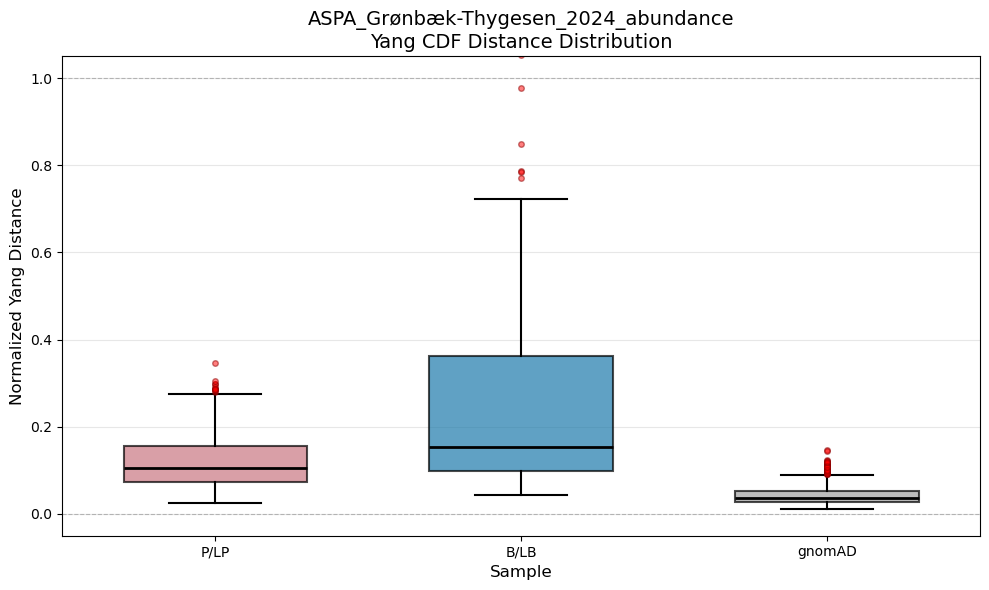

In [126]:
# 2. Create box plots for a specific dataset
fig = plot_yang_distance_boxplots('ASPA_Grønbæk-Thygesen_2024_abundance', all_yang_dists)
# if fig is not None:
    # fig.savefig('/data/ross/assay_calibration/yang_boxplot_BRCA1.png', dpi=300, bbox_inches='tight')
    # plt.close(fig)

In [ ]:

sample_colors = {
    'pathogenic': '#CA7682',
    'benign': '#1D7AAB',
    'gnomad': '#A0A0A0',
    'synonymous': '#6BAA75'
}

sample_labels = {
    'pathogenic': 'P/LP',
    'benign': 'B/LB',
    'gnomad': 'gnomAD',
    'synonymous': 'Synonymous'
}

def plot_yang_distance_comparison(dataset_names, all_yang_dists, figsize=(10, 8.3333333)):
    """
    Create a 2x2 grid comparison of Yang distances across datasets.
    Automatically adjusts row count based on samples present.
    
    Parameters:
    -----------
    dataset_names : list of str
        List of 4 dataset names to compare
    all_yang_dists : dict
        Dictionary with yang distances for all datasets
    figsize : tuple
        Figure size (default: (12, 10))
    
    Returns:
    --------
    matplotlib figure
    """
    
    if len(dataset_names) != 4:
        raise ValueError("Must provide exactly 4 dataset names")
    
    # Sample configuration
    sample_order = ['pathogenic', 'benign', 'gnomad', 'synonymous']
    panel_letters = ['A', 'B', 'C', 'D']
    
    # Create figure with 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    for idx, (ax, dataset_name) in enumerate(zip(axes, dataset_names)):

        scoreset = Scoreset(df[df["Dataset"] == dataset_name])
        
        if dataset_name not in all_yang_dists:
            ax.text(0.5, 0.5, f'Dataset not found:\n{dataset_name}', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
        
        yang_data = all_yang_dists[dataset_name]
        
        # Prepare data for this dataset - only include existing samples
        plot_data = []
        y_labels = []
        y_labels_minimal = []
        colors = []

        sample_count = 0
        for sample in sample_order:
            if sample not in yang_data:
                continue
            
            dists = yang_data[sample]
            valid_dists = dists[~np.isnan(dists)]
            
            if len(valid_dists) == 0:
                continue

            
            n = scoreset.sample_counts[sample_count]
            sample_count += 1
            
            plot_data.append(valid_dists)
            
            # Create label with count
            # n_count = len(valid_dists)
            y_labels.append(f"{sample_labels[sample]}\n(n={n})")
            y_labels_minimal.append(f"(n={n})")
            colors.append(sample_colors[sample])
        
        if len(plot_data) == 0:
            ax.text(0.5, 0.5, 'No valid data', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
        
        # Create positions: 1, 2, 3, (4 if exists)
        n_samples = len(plot_data)
        y_positions = list(range(1, n_samples + 1))
        
        # Create horizontal boxplot
        bp = ax.boxplot(
            plot_data,
            positions=y_positions,
            vert=False,  # Horizontal orientation
            patch_artist=True,
            widths=0.6,
            medianprops=dict(color='black', linewidth=1.5),
            boxprops=dict(linewidth=1.2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            showfliers=True,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, 
                          alpha=0.5, markeredgecolor='darkgray', linewidth=0.5)
        )
        
        # Color boxes
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        # Set y-axis (sample names)
        ax.set_yticks(y_positions)
        ax.set_ylim(0.5, n_samples + 0.5)  # Dynamic based on sample count
        
        # Show y-labels on leftmost panels (idx 0 and 2)
        if idx % 2 == 0:  # Left column (0, 2)
            ax.set_yticklabels(y_labels, fontsize=12)
        else:
            ax.set_yticklabels(y_labels_minimal, fontsize=12)
        
        # Invert y-axis so P/LP is on top
        ax.invert_yaxis()
        
        # Set x-axis label only on bottom row (idx 2 and 3)
        if idx >= 2:  # Bottom row
            ax.set_xlabel('Distance', fontsize=12)
        
        # Calculate natural x-axis limit and cap at 1.0
        max_data_value = max([max(d) for d in plot_data])
        natural_xlim = 1.10 * max_data_value
        xlim_upper = min(natural_xlim, 1.0)
        
        ax.set_xlim(0, xlim_upper)
        
        # Grid
        ax.grid(True, alpha=0.3, axis='x', linewidth=0.5)
        ax.set_axisbelow(True)
        
        # Title: gene name
        gene_name = dataset_name.split('_')[0]
        author_name = dataset_name.split('_')[1]
        ax.text(0.00, 1.08, f"({panel_letters[idx]})", 
            transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            verticalalignment='top',
            horizontalalignment='left')

        # Gene and author name centered
        ax.set_title(rf"$\mathbfit{{{gene_name}}}$ – {author_name}",
             fontsize=14, fontweight='bold', pad=8)
        
        # Clean up spines
        # ax.spines['top'].set_visible(False)
        # ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    return fig


# Usage example:
datasets_to_compare = [
    "BRCA1_Findlay_2018",
    "GCK_Gersing_2024_abundance",
    "PTEN_Mighell_2018",
    "CRX_Shepherdson_2024"
]

fig = plot_yang_distance_comparison(datasets_to_compare, all_yang_dists)
plt.savefig('/data/ross/assay_calibration/yang_boxplots/yang_distance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [169]:
import json

dataset_configs = {
    "ASPA_Grønbæk-Thygesen_2024_abundance": ("3c", "avg"),
    "ASPA_Grønbæk-Thygesen_2024_toxicity": ("3c", "avg"),
    "BARD1_unpublished": ("2c", "avg"),
    "CALM1_CALM2_CALM3_Weile_2017": ("3c", "avg"),
    "CARD11_Meitlis_2020_DMSO_no_introns": ("3c", "avg"),
    "CARD11_Meitlis_2020_Ibrutinib_no_introns": ("3c", "avg"),
    "CBS_Sun_2020_high_B6": ("3c", "avg"),
    "CBS_Sun_2020_low_B6": ("2c", "avg"),
    "CHK2_Gebbia_2024": ("2c", "benign"),
    "CHEK2_Gebbia_2024": ("2c", "benign"),
    "CRX_Shepherdson_2024": ("2c", "avg"),
    "CTCF_unpublished": ("2c", "avg"),
    "F9_Popp_2025_carboxy_F9_specific": ("3c", "avg"),
    "F9_Popp_2025_carboxy_gla_motif": ("3c", "avg"),
    "F9_Popp_2025_heavy_chain": ("3c", "benign"),
    "F9_Popp_2025_light_chain": ("3c", "benign"),
    "F9_Popp_2025_strep_2": ("3c", "avg"),
    "FKRP_Ma_2024": ("3c", "avg"),
    "G6PD_unpublished": ("2c", "avg"),
    "GCK_Gersing_2023_complementation": ("3c", "avg"),
    "GCK_Gersing_2024_abundance": ("2c", "avg"),
    "HMBS_van_Loggerenberg_2023_combined": ("3c", "avg"),
    "HMBS_van_Loggerenberg_2023_erythroid": ("3c", "avg"),
    "HMBS_van_Loggerenberg_2023_ubquitous": ("2c", "avg"),
    "JAG1_Gilbert_2024": ("3c", "avg"),
    "KCNE1_Muhammad_2024_absence_of_WT": ("3c", "avg"),
    "KCNE1_Muhammad_2024_potassium_flux": ("2c", "avg"),
    "KCNE1_Muhammad_2024_presence_of_WT": ("2c", "avg"),
    "KCNH2_Jiang_2022": ("2c", "avg"),
    "KCNH2_O_Neill_2024_surface_expression": ("3c", "avg"),
    "KCNQ4_Zheng_2022_current_homozygous": ("3c", "avg"),
    "KCNQ4_Zheng_2022_v12_homozygous": ("2c", "avg"),
    "LARGE1_Ma_2024": ("3c", "avg"),
    "MSH2_Jia_2021": ("2c", "avg"),
    "NDUFAF6_Sung_2024": ("2c", "avg"),
    "OTC_Lo_2023": ("3c", "avg"),
    "PALB2_unpublished": ("2c", "avg"),
    "PAX6_McDonnell_2024_BLX_geneticin": ("3c", "avg"),
    "PAX6_McDonnell_2024_BLX_no_geneticin": ("3c", "avg"),
    "PAX6_McDonnell_2024_LE9_geneticin": ("2c", "avg"),
    "PAX6_McDonnell_2024_LE9_no_geneticin": ("2c", "avg"),
    "RAD51D_unpublished": ("3c", "avg"),
    "RHO_Wan_2019": ("2c", "avg"),
    "SCN5A_Glazer_2020": ("3c", "avg"),
    "SCN5A_Ma_2024_current_density": ("2c", "avg"),
    "TP53_Boettcher_2019": ("2c", "avg"),
    "TP53_Fortuno_2021_Kato_meta": ("2c", "avg"),
    "TP53_Giacomelli_2018_combined_score": ("2c", "avg"),
    "TP53_Giacomelli_2018_p53WT_Nutlin3": ("2c", "avg"),
    "TP53_Giacomelli_2018_p53null_Nutlin3": ("2c", "avg"),
    "TP53_Giacomelli_2018_p53null_etoposide": ("2c", "avg"),
    "TP53_Kato_2003_AIP1nWT": ("3c", "avg"),
    "TP53_Kato_2003_BAXnWT": ("3c", "avg"),
    "TP53_Kato_2003_GADD45nWT": ("2c", "avg"),
    "TP53_Kato_2003_MDM2nWT": ("3c", "avg"),
    "TP53_Kato_2003_NOXAnWT": ("3c", "avg"),
    "TP53_Kato_2003_P53R2nWT": ("2c", "avg"),
    "TP53_Kato_2003_WAF1nWT": ("3c", "avg"),
    "TP53_Kato_2003_h1433snWT": ("3c", "avg"),
    "TPK1_Weile_2017": ("2c", "avg"),
    "TSC2_rapgap_unpublished": ("3c", "avg"),
    "TSC2_tuberin_unpublished": ("3c", "avg"),
    "XRCC2_unpublished": ("2c", "avg"),
    "BAP1_Waters_2024": ("3c", "avg"),
    "BRCA1_Adamovich_2022_Cisplatin": ("2c", "avg"),
    "BRCA1_Adamovich_2022_HDR": ("2c", "avg"),
    "BRCA1_Findlay_2018": ("2c", "avg"),
    "BRCA2_Hu_2024": ("2c", "avg"),
    "BRCA2_Sahu_2023_exon13_Cisplatin": ("3c", "benign"),
    "BRCA2_Sahu_2023_exon13_Olaparib": ("2c", "avg"),
    "BRCA2_Sahu_2023_exon13_SGE": ("3c", "benign"),
    "BRCA2_Sahu_2023_exon13_global_score": ("2c", "avg"),
    "BRCA2_Sahu_2025_HDR": ("2c", "avg"),
    "BRCA2_unpublished": ("3c", "avg"),
    "DDX3X_Radford_2023_cLFC_day15": ("2c", "benign"),
    # "PTEN_Matreyek_2018": ("2c", "avg"), # replace with filtered nonsense
    "PTEN_Mighell_2018": ("2c", "avg"),
    "RAD51C_Olvera-León_2024_z_score_D4_D14": ("2c", "avg"),
    "VHL_Buckley_2024": ("2c", "benign"),
    "BAP1_Waters_2024_clinvar_2018": ("3c", "avg"),
    "BRCA1_Adamovich_2022_Cisplatin_clinvar_2018": ("2c", "avg"),
    "BRCA1_Adamovich_2022_HDR_clinvar_2018": ("2c", "avg"),
    "BRCA1_Findlay_2018_clinvar_2018": ("2c", "avg"),
    "BRCA2_Hu_2024_clinvar_2018": ("2c", "avg"),
    "BRCA2_Sahu_2023_exon13_Cisplatin_clinvar_2018": ("3c", "avg"),
    "BRCA2_Sahu_2023_exon13_Olaparib_clinvar_2018": ("2c", "avg"),
    "BRCA2_Sahu_2023_exon13_SGE_clinvar_2018": ("3c", "avg"),
    "BRCA2_Sahu_2023_exon13_global_score_clinvar_2018": ("3c", "avg"),
    "BRCA2_Sahu_2025_HDR_clinvar_2018": ("2c", "avg"),
    "BRCA2_unpublished_clinvar_2018": ("2c", "avg"),
    "DDX3X_Radford_2023_cLFC_day15_clinvar_2018": ("2c", "avg"),
    # "PTEN_Matreyek_2018_clinvar_2018": ("2c", "avg"), # replace with filtered nonsense
    "PTEN_Mighell_2018_clinvar_2018": ("2c", "avg"),
    "RAD51C_Olvera-León_2024_z_score_D4_D14_clinvar_2018": ("2c", "avg"),
    "VHL_Buckley_2024_clinvar_2018": ("2c", "benign"),
    "KCNH2_Kozek_Glazer_2020": ("3c", "avg"),
    "TP53_Fayer_2021_meta": ("2c", "avg"),
    "TARDBP_Bolognesi_Faure_2019": ("3c", "avg"),
    "SGCB_Li_2023": ("2c", "avg"),
    "SFPQ_unpublished": ("2c", "avg")
}

dataset_relax_configs = {
    "BARD1_unpublished": ("2c", "avg"),
    "DDX3X_Radford_2023_cLFC_day15": ("2c", "avg"),
    "DDX3X_Radford_2023_cLFC_day15_clinvar_2018": ("2c", "avg"),
    # "FKRP_Ma_2024": ("3c", "avg"),
    # "G6PD_unpublished": ("3c", "avg"),
    "HMBS_van_Loggerenberg_2023_combined": ("2c", "avg"),
    "HMBS_van_Loggerenberg_2023_erythroid": ("3c", "avg"),
    "HMBS_van_Loggerenberg_2023_ubquitous": ("3c", "avg"),
    "KCNE1_Muhammad_2024_presence_of_WT": ("2c", "avg"),
    # "KCNH2_O_Neill_2024_surface_expression": ("3c", "avg"), # KEEP CONSTRAINED 3c avg # only compute lr+ when densities are high enough, extend
    # "LARGE1_Ma_2024": ("3c", "avg"), # KEEP CONSTRAINED
    "PTEN_Matreyek_2018_filtered_nonsense": ("2c", "avg"),
    "PTEN_Matreyek_2018_filtered_nonsense_clinvar_2018": ("2c", "avg"),
    "RAD51C_Olvera-León_2024_z_score_D4_D14": ("3c", "avg"), # ENFORCE 10e-3 on normalized densities 0-1 
    "RAD51C_Olvera-León_2024_z_score_D4_D14_clinvar_2018": ("3c", "avg"),
    "RAD51D_unpublished": ("2c", "avg"),
    # "TSC2_Calhoun_cliPE_unpublished": ("2c", "avg"),
    # "TSC2_Calhoun_immuneSGE_unpublished": ("2c", "avg"),
    "TSC2_tuberin_unpublished": ("3c", "avg"),
    "VHL_Buckley_2024": ("3c", "avg"),
    "VHL_Buckley_2024_clinvar_2018": ("3c", "avg"),
    # "XRCC2_unpublished": ("2c", "avg"), 
    
    # new 11_22_25 rerun datasets (all relax)
    "CALM1_CALM2_CALM3_Weile_2017": ("3c", "avg"),
    "G6PD_unpublished": ("3c", "avg"),
    "MSH2_Jia_2021_clinvar_2018": ("2c", "avg"),
    "TP53_Boettcher_2019_clinvar_2018": ("2c", "avg"),
    "TP53_Fortuno_2021_Kato_meta_clinvar_2018": ("2c", "avg"),
    "TP53_Giacomelli_2018_combined_score_clinvar_2018": ("2c", "avg"),
    "TP53_Giacomelli_2018_p53WT_Nutlin3_clinvar_2018": ("2c", "avg"),
    "TP53_Giacomelli_2018_p53null_Nutlin3_clinvar_2018": ("2c", "avg"),
    "TP53_Giacomelli_2018_p53null_etoposide_clinvar_2018": ("2c", "avg"),
    "TP53_Kato_2003_AIP1nWT_clinvar_2018": ("3c", "avg"),
    "TP53_Kato_2003_BAXnWT_clinvar_2018": ("3c", "avg"),
    "TP53_Kato_2003_GADD45nWT_clinvar_2018": ("2c", "avg"),
    "TP53_Kato_2003_MDM2nWT_clinvar_2018": ("3c", "avg"),
    "TP53_Kato_2003_NOXAnWT_clinvar_2018": ("3c", "avg"),
    "TP53_Kato_2003_P53R2nWT_clinvar_2018": ("2c", "avg"),
    "TP53_Kato_2003_WAF1nWT_clinvar_2018": ("3c", "avg"),
    "TP53_Kato_2003_h1433snWT_clinvar_2018": ("3c", "avg"),
    "TPK1_Weile_2017": ("2c", "avg"),
    "XRCC2_unpublished": ("2c", "avg"),
    "LARGE1_Ma_2024": ("3c", "avg"),
    "FKRP_Ma_2024": ("3c", "avg"),
}


with open('/data/ross/assay_calibration/new_dataset_configs.json','rt') as f:
    new_dataset_configs = json.load(f)

keep_old_list = set()
with open('/data/ross/assay_calibration/keep_old_datasets.txt','r') as f:
    for line in f:
        keep_old_list.add(line.strip())


In [54]:
keep_old_list

{'BRCA2_Sahu_2023_exon13_SGE',
 'BRCA2_Sahu_2023_exon13_SGE_clinvar_2018',
 'CBS_Sun_2020_high_B6',
 'F9_Popp_2025_carboxy_F9_specific',
 'F9_Popp_2025_carboxy_gla_motif',
 'F9_Popp_2025_heavy_chain',
 'F9_Popp_2025_light_chain',
 'F9_Popp_2025_strep_2',
 'GCK_Gersing_2024_abundance',
 'KCNE1_Muhammad_2024_absence_of_WT',
 'OTC_Lo_2023',
 'PAX6_McDonnell_2024_LE9_geneticin',
 'PAX6_McDonnell_2024_LE9_no_geneticin',
 'TP53_Fortuno_2021_Kato_meta',
 'TP53_Fortuno_2021_Kato_meta_clinvar_2018',
 'TP53_Kato_2003_BAXnWT',
 'TP53_Kato_2003_BAXnWT_clinvar_2018',
 'TP53_Kato_2003_MDM2nWT',
 'TP53_Kato_2003_MDM2nWT_clinvar_2018',
 'TSC2_tuberin_unpublished'}

In [59]:
# import glob
# import pickle
# from collections import defaultdict

# dataset_to_splits = defaultdict(dict)

# for dataset in new_dataset_configs:
#     print(f"\n\n{dataset}\n")
    
#     keep_old = dataset in keep_old_list
#     mode = "explorer_jobs_replicate_run"
#     if keep_old:
#         if dataset in dataset_relax_configs:
#             relax = True
#             mode = "explorer_jobs_semifinal_run"
#         else:
#             relax = False
#             mode = "explorer_jobs"
#             if dataset.endswith('_clinvar_2018'):
#                 mode = "explorer_jobs_clinvar_2018"

#     for job_array_f in glob.glob(f"/data/ross/assay_calibration/{mode}/jobs/array_*.pkl"):
#         with open(job_array_f, "rb") as f:
#             job_array = pickle.load(f)
        
#         for job in job_array:
#             if (dataset == job["dataset_name"] or job["dataset_name"] not in keep_old_list) and len(dataset_to_splits[job["dataset_name"]]) < 1000:
#                 dataset_to_splits[job["dataset_name"]][job["bootstrap_seed"]] = job["shared_data"]
#                 print(f"recovered {job['dataset_name']} {job['bootstrap_seed']}")
#                 if len(dataset_to_splits[job["dataset_name"]]) == 1000:
#                     break
            
#     break
    



ASPA_Grønbæk-Thygesen_2024_abundance

recovered BRCA1_Findlay_2018 0
recovered BRCA1_Findlay_2018 1
recovered BRCA1_Findlay_2018 2
recovered BRCA1_Findlay_2018 3
recovered BRCA1_Findlay_2018 4
recovered BRCA1_Findlay_2018 5
recovered BRCA1_Findlay_2018 6
recovered BRCA1_Findlay_2018 7
recovered BRCA1_Findlay_2018 8
recovered BRCA1_Findlay_2018 9
recovered BRCA1_Findlay_2018 10
recovered BRCA1_Findlay_2018 11
recovered BRCA1_Findlay_2018 12
recovered BRCA1_Findlay_2018 13
recovered BRCA1_Findlay_2018 14
recovered BRCA1_Findlay_2018 15
recovered BRCA1_Findlay_2018 16
recovered BRCA1_Findlay_2018 17
recovered BRCA1_Findlay_2018 18
recovered BRCA1_Findlay_2018 19
recovered BRCA1_Findlay_2018 20
recovered BRCA1_Findlay_2018 21
recovered BRCA1_Findlay_2018 22
recovered BRCA1_Findlay_2018 23
recovered BRCA1_Findlay_2018 24
recovered BRCA1_Findlay_2018 25
recovered BRCA1_Findlay_2018 26
recovered BRCA1_Findlay_2018 27
recovered BRCA1_Findlay_2018 28
recovered BRCA1_Findlay_2018 29
recovered 

KeyboardInterrupt: 

In [238]:
import glob
import pickle
from collections import defaultdict
from joblib import Parallel, delayed
import os
from typing import Dict, Set, Tuple, List



def load_single_pkl_file(filepath: str, target_datasets: Set[str], 
                         max_splits: int, current_counts: Dict[str, int]) -> Dict:
    """
    Load a single pkl file and extract relevant jobs.
    
    Returns dict of {dataset_name: {bootstrap_seed: shared_data}}
    """
    results = defaultdict(dict)
    
    try:
        with open(filepath, "rb") as f:
            job_array = pickle.load(f)
        
        for job in job_array:
            job_dataset = job.get("dataset_name", "")
            
            # Skip if not a target dataset
            if job_dataset not in target_datasets:
                continue
            
            # Skip if already have enough splits (use atomic check)
            if current_counts.get(job_dataset, 0) >= max_splits:
                continue
            
            bootstrap_seed = job.get("bootstrap_seed")
            shared_data = job.get("shared_data")
            
            if bootstrap_seed is not None and shared_data is not None:
                if bootstrap_seed not in results[job_dataset]:
                    results[job_dataset][bootstrap_seed] = shared_data
    
    except Exception as e:
        print(f"  Error loading {filepath}: {e}")
    
    return dict(results)



def get_replicate_directory(dataset: str) -> str:
    """
    Determine which replicate directory a non-keep_old dataset belongs to.
    
    Returns the specific directory name.
    """
    if dataset.endswith('_clinvar_2018'):
        return "explorer_jobs_replicate_run_2018"
    elif dataset in ["TARDBP_Bolognesi_Faure_2019", "SGCB_Li_2023", "SFPQ_unpublished"]:
        return "explorer_jobs_replicate_run_PU"
    elif dataset == "TSC2_combined_unpublished":
        return "explorer_jobs_tsc2"
    elif dataset in ['BAP1_Waters_2024','RAD51C_Olvera-León_2024_z_score_D4_D14']:
        return "explorer_jobs_bap1_rad51c"
    else:
        return "explorer_jobs_replicate_run"


def process_directory_parallel(mode: str, target_datasets: Set[str], 
                               base_path: str, max_splits: int,
                               jobs_subdir: str = "jobs",
                               n_jobs: int = -1) -> Dict:
    """
    Process all pkl files in a directory in parallel.
    
    Returns dict of {dataset_name: {bootstrap_seed: shared_data}}
    """
    jobs_dir = f"{base_path}/{mode}/{jobs_subdir}"
    
    if not os.path.exists(jobs_dir):
        print(f"  Directory not found: {jobs_dir}")
        return {}
    
    # Get all pkl files
    pkl_files = sorted(glob.glob(f"{jobs_dir}/array_*.pkl"))
    
    if not pkl_files:
        print(f"  No pkl files found in {jobs_dir}")
        return {}
    
    print(f"  {mode}: Loading {len(pkl_files)} pkl files with {n_jobs if n_jobs > 0 else 'all'} jobs...")
    
    # Track current counts to enable early stopping
    current_counts = defaultdict(int)
    all_results = defaultdict(dict)
    
    # Process in batches to allow early stopping
    batch_size = 100
    for batch_start in range(0, len(pkl_files), batch_size):
        batch_files = pkl_files[batch_start:batch_start + batch_size]
        
        # Load batch in parallel
        batch_results = Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(load_single_pkl_file)(
                filepath, target_datasets, max_splits, current_counts
            )
            for filepath in batch_files
        )
        
        # Merge results
        for result in batch_results:
            for dataset, splits in result.items():
                for bootstrap_seed, shared_data in splits.items():
                    if bootstrap_seed not in all_results[dataset]:
                        all_results[dataset][bootstrap_seed] = shared_data
                        current_counts[dataset] += 1
        
        # Check if all datasets are complete
        if all(current_counts.get(d, 0) >= max_splits for d in target_datasets):
            print(f"    All target datasets complete, stopping early after {batch_start + len(batch_files)} files")
            break
        
        # Progress update
        complete = sum(1 for d in target_datasets if current_counts.get(d, 0) >= max_splits)
        print(f"    Batch {batch_start//batch_size + 1}: {complete}/{len(target_datasets)} datasets complete")
    
    return dict(all_results)

def get_dataset_directory(dataset: str, keep_old_list: List[str], 
                          dataset_relax_configs: Dict) -> str:
    """Determine the correct directory for a keep_old dataset."""
    if dataset not in keep_old_list:
        raise ValueError(f"Dataset {dataset} is not in keep_old_list")
    
    if dataset in dataset_relax_configs:
        return "explorer_jobs_semifinal_run"
    elif dataset.endswith('_clinvar_2018'):
        return "explorer_jobs_old_clinvar"
    else:
        return "explorer_jobs"


def get_all_keep_old_directories() -> List[str]:
    """Get all possible directories that might contain keep_old datasets."""
    return [
        "explorer_jobs",
        "explorer_jobs_old_clinvar",
        "explorer_jobs_semifinal_run",
        "explorer_jobs_12_01_25_rerun",
        "explorer_jobs_12_04_25_rerun",
        "explorer_jobs_circular_clinvar"
    ]


def recover_all_datasets_optimized(
    dataset_configs: Dict,
    keep_old_list: List[str],
    dataset_relax_configs: Dict,
    base_path: str = "/data/ross/assay_calibration",
    max_splits: int = 1000,
    n_jobs: int = -1
) -> Dict:
    """
    Efficiently recover splits for all datasets.
    For _clinvar_2018 datasets, falls back to keep_old directories if not found in replicate.
    """
    
    print("="*80)
    print("OPTIMIZED SPLIT RECOVERY")
    print("="*80)
    
    # Separate datasets into keep_old and non_keep_old
    keep_old_datasets = set(d for d in dataset_configs if d in keep_old_list)
    non_keep_old_datasets = set(d for d in dataset_configs if d not in keep_old_list)
    
    print(f"\nDatasets to process:")
    print(f"  Keep old: {len(keep_old_datasets)}")
    print(f"  New (non-keep_old): {len(non_keep_old_datasets)}")
    
    all_results = {}
    
    # ========================================================================
    # PART 1: Process keep_old datasets
    # ========================================================================
    if keep_old_datasets:
        print(f"\n{'='*80}")
        print("PART 1: Processing keep_old datasets")
        print('='*80)
        
        # Group keep_old datasets by directory
        datasets_by_dir = defaultdict(set)
        for dataset in keep_old_datasets:
            directory = get_dataset_directory(dataset, keep_old_list, dataset_relax_configs)
            datasets_by_dir[directory].add(dataset)
        
        print(f"\nGrouped into {len(datasets_by_dir)} directories:")
        for directory, datasets in sorted(datasets_by_dir.items()):
            print(f"  {directory}: {len(datasets)} datasets")
        
        # Process each directory
        for directory, datasets in datasets_by_dir.items():
            print(f"\nProcessing {directory}...")
            
            results = process_directory_parallel(
                mode=directory,
                target_datasets=datasets,
                base_path=base_path,
                max_splits=max_splits,
                jobs_subdir="jobs",
                n_jobs=n_jobs
            )
            
            # Merge results
            for dataset, splits in results.items():
                all_results[dataset] = splits
                print(f"  {dataset}: {len(splits)}/{max_splits} splits")
        
        # Check additional directories for any missing keep_old datasets
        missing_keep_old = [d for d in keep_old_datasets if len(all_results.get(d, {})) < max_splits]
        
        if missing_keep_old:
            print(f"\n{'='*80}")
            print(f"Checking additional directories for {len(missing_keep_old)} incomplete keep_old datasets")
            print('='*80)
            
            additional_dirs = [
                "explorer_jobs_12_01_25_rerun",
                "explorer_jobs_12_04_25_rerun",
                "explorer_jobs_circular_clinvar"
            ]
            
            for directory in additional_dirs:
                incomplete = [d for d in missing_keep_old if len(all_results.get(d, {})) < max_splits]
                
                if not incomplete:
                    break
                
                print(f"\n{directory}: Checking {len(incomplete)} datasets...")
                
                results = process_directory_parallel(
                    mode=directory,
                    target_datasets=set(incomplete),
                    base_path=base_path,
                    max_splits=max_splits,
                    jobs_subdir="jobs",
                    n_jobs=n_jobs
                )
                
                for dataset, splits in results.items():
                    if len(splits) > len(all_results.get(dataset, {})):
                        all_results[dataset] = splits
                        print(f"  ✓ {dataset}: {len(splits)}/{max_splits} splits")
    
    # ========================================================================
    # PART 2: Process non_keep_old datasets
    # ========================================================================
    if non_keep_old_datasets:
        print(f"\n{'='*80}")
        print("PART 2: Processing non-keep_old datasets")
        print('='*80)
        
        # Group non-keep_old datasets by directory
        datasets_by_dir = defaultdict(set)
        for dataset in non_keep_old_datasets:
            directory = get_replicate_directory(dataset)
            datasets_by_dir[directory].add(dataset)
        
        print(f"\nGrouped into {len(datasets_by_dir)} directories:")
        for directory, datasets in sorted(datasets_by_dir.items()):
            print(f"  {directory}: {len(datasets)} datasets")
        
        # Process each directory
        for directory, datasets in datasets_by_dir.items():
            print(f"\nProcessing {directory}...")
            
            if directory == "explorer_jobs_replicate_run_PU":
                jobs_ext = "jobs_PU"
            elif directory == "explorer_jobs_replicate_run_2018":
                jobs_ext = "jobs_2018"
            else:
                jobs_ext = "jobs"
            
            results = process_directory_parallel(
                mode=directory,
                target_datasets=datasets,
                base_path=base_path,
                max_splits=max_splits,
                jobs_subdir=jobs_ext,
                n_jobs=n_jobs
            )
            
            # Merge results
            for dataset, splits in results.items():
                all_results[dataset] = splits
                print(f"  {dataset}: {len(splits)}/{max_splits} splits")
    
    # ========================================================================
    # PART 3: Fallback for _clinvar_2018 datasets not found in replicate
    # ========================================================================
    print(f"\n{'='*80}")
    print("PART 3: Checking fallback for missing _clinvar_2018 datasets")
    print('='*80)
    
    # Find _clinvar_2018 datasets that weren't found or are incomplete
    missing_clinvar_2018 = [
        d for d in dataset_configs 
        if d.endswith('_clinvar_2018') 
        and d not in keep_old_list
        and len(all_results.get(d, {})) < max_splits
    ]
    
    if missing_clinvar_2018:
        print(f"\nFound {len(missing_clinvar_2018)} _clinvar_2018 datasets to check in keep_old directories:")
        for d in missing_clinvar_2018:
            print(f"  {d}: {len(all_results.get(d, {}))}/{max_splits}")
        
        # Try to find them in keep_old directories (including additional directories)
        fallback_dirs = [
            "explorer_jobs_old_clinvar",
            "explorer_jobs",
            "explorer_jobs_12_01_25_rerun",
            "explorer_jobs_12_04_25_rerun",
            "explorer_jobs_circular_clinvar"
        ]
        
        for directory in fallback_dirs:
            # Only check datasets still incomplete
            incomplete = [d for d in missing_clinvar_2018 if len(all_results.get(d, {})) < max_splits]
            
            if not incomplete:
                print(f"\nAll datasets complete, skipping remaining directories")
                break
            
            print(f"\n{directory}: Checking {len(incomplete)} datasets as fallback...")
            
            results = process_directory_parallel(
                mode=directory,
                target_datasets=set(incomplete),
                base_path=base_path,
                max_splits=max_splits,
                jobs_subdir="jobs",
                n_jobs=n_jobs
            )
            
            # Merge results (only if we don't have better results already)
            for dataset, splits in results.items():
                if len(splits) > len(all_results.get(dataset, {})):
                    all_results[dataset] = splits
                    print(f"  ✓ {dataset}: {len(splits)}/{max_splits} splits (fallback)")
    else:
        print("\nNo missing _clinvar_2018 datasets to check")
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    print("\n" + "="*80)
    print("RECOVERY COMPLETE")
    print("="*80)
    
    complete = sum(1 for splits in all_results.values() if len(splits) == max_splits)
    partial = sum(1 for splits in all_results.values() if 0 < len(splits) < max_splits)
    empty = sum(1 for splits in all_results.values() if len(splits) == 0)
    missing = len(dataset_configs) - len(all_results)
    
    print(f"\nResults:")
    print(f"  Complete ({max_splits} splits): {complete}")
    print(f"  Partial: {partial}")
    print(f"  Empty: {empty}")
    print(f"  Missing: {missing}")
    
    # Show problematic datasets
    if partial > 0 or empty > 0 or missing > 0:
        print("\nDatasets with issues:")
        
        for dataset in sorted(dataset_configs.keys()):
            splits = all_results.get(dataset, {})
            n_splits = len(splits)
            
            if n_splits < max_splits:
                # Determine which directory this dataset should be in
                if dataset in keep_old_list:
                    directory = get_dataset_directory(dataset, keep_old_list, dataset_relax_configs)
                    full_path = f"{directory}/jobs"
                else:
                    directory = get_replicate_directory(dataset)
                    if directory == "explorer_jobs_replicate_run_PU":
                        jobs_ext = "jobs_PU"
                    elif directory == "explorer_jobs_replicate_run_2018":
                        jobs_ext = "jobs_2018"
                    else:
                        jobs_ext = "jobs"
                    full_path = f"{directory}/{jobs_ext}"
                
                print(f"  {dataset}: {n_splits}/{max_splits} ({full_path})")
    
    return all_results


# Usage:
# if __name__ == "__main__":
    
#     dataset_to_splits = recover_all_datasets_optimized(
#         dataset_configs=new_dataset_configs,
#         keep_old_list=keep_old_list,
#         dataset_relax_configs=dataset_relax_configs,
#         base_path="/data/ross/assay_calibration",
#         max_splits=1000,
#         n_jobs=20  # Parallel loading of pkl files
#     )
    
#     # Save results
#     output_file = "/data/ross/assay_calibration/dataset_splits_recovered.pkl"
#     with open(output_file, "wb") as f:
#         pickle.dump(dataset_to_splits, f)
    
#     print(f"\nResults saved to {output_file}")


# output_file = "/data/ross/assay_calibration/dataset_splits_recovered.pkl"
# with open(output_file, "rb") as f:
#     dataset_to_splits = pickle.load(f)

# print("len(dataset_to_splits)", len(dataset_to_splits))

# dataset_to_add = "TP53_Fayer_2021_meta_clinvar_2018"

# dataset_to_splits = {**dataset_to_splits, **recover_all_datasets_optimized(
#     dataset_configs={dataset_to_add: new_dataset_configs[dataset_to_add]},
#     keep_old_list=keep_old_list,
#     dataset_relax_configs=dataset_relax_configs,
#     base_path="/data/ross/assay_calibration",
#     max_splits=1000,
#     n_jobs=20  # Parallel loading of pkl files
# )}

# print("len(dataset_to_splits)", len(dataset_to_splits))

len(dataset_to_splits) 116
OPTIMIZED SPLIT RECOVERY

Datasets to process:
  Keep old: 0
  New (non-keep_old): 1

PART 2: Processing non-keep_old datasets

Grouped into 1 directories:
  explorer_jobs_replicate_run_2018: 1 datasets

Processing explorer_jobs_replicate_run_2018...
  explorer_jobs_replicate_run_2018: Loading 1000 pkl files with 20 jobs...


Traceback (most recent call last):
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_details
  File "/home/rcstewart/miniconda3/envs/assay_calibration/lib/python3.11/site-packages/joblib/__init__.py", line 114, in <module>
  File "/home/rcstewart/miniconda3/envs/assay_calibration/lib/python3.11/site-packages/joblib/__init__.py", line 114, in <module>
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
  File "/home/rcstewart/miniconda3/envs/assay_calibration/lib/python3.11/site-packages/joblib/__init__.py", line 114, in <module>
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
  File

In [32]:
with open(output_file, "wb") as f:
    pickle.dump(dataset_to_splits, f)

In [239]:
import glob
import pickle
from collections import defaultdict
from joblib import Parallel, delayed
import os
from typing import Dict, Set, Tuple, List

# [Keep all the function definitions: load_single_pkl_file, get_replicate_directory, 
#  process_directory_parallel, get_dataset_directory, get_all_keep_old_directories,
#  and recover_all_datasets_optimized exactly as they are above]

# ... [all function definitions remain the same] ...

# ========================================================================
# Load existing dataset_to_splits
# ========================================================================
print("="*80)
print("LOADING EXISTING DATASET SPLITS")
print("="*80)

input_file = "/data/ross/assay_calibration/dataset_splits_recovered.pkl"
with open(input_file, "rb") as f:
    dataset_to_splits = pickle.load(f)

print(f"Loaded {len(dataset_to_splits)} existing datasets from {input_file}")

# ========================================================================
# Add new dataset(s)
# ========================================================================
print("\n" + "="*80)
print("ADDING NEW DATASET(S)")
print("="*80)

datasets_to_add = ['BAP1_Waters_2024','RAD51C_Olvera-León_2024_z_score_D4_D14']#["TSC2_combined_unpublished"]  # Can add multiple datasets
# new_dataset_configs[datasets_to_add[0]] = ("3c", "avg")

for dataset_to_add in datasets_to_add:
    print(f"\nProcessing: {dataset_to_add}")
    
    if dataset_to_add in dataset_to_splits:
        print(f"  Warning: {dataset_to_add} already exists with {len(dataset_to_splits[dataset_to_add])} splits")
        print(f"  Will overwrite if new recovery finds more splits")
    
    # Recover the new dataset
    new_splits = recover_all_datasets_optimized(
        dataset_configs={dataset_to_add: new_dataset_configs[dataset_to_add]},
        keep_old_list=keep_old_list,
        dataset_relax_configs=dataset_relax_configs,
        base_path="/data/ross/assay_calibration",
        max_splits=1000,
        n_jobs=20
    )
    
    # Merge into existing dictionary
    dataset_to_splits.update(new_splits)
    
    if dataset_to_add in new_splits:
        print(f"  ✓ Added {dataset_to_add} with {len(new_splits[dataset_to_add])} splits")
    else:
        print(f"  ✗ Failed to recover {dataset_to_add}")

# ========================================================================
# Save updated dataset_to_splits
# ========================================================================
print("\n" + "="*80)
print("SAVING UPDATED DATASET SPLITS")
print("="*80)

output_file = "/data/ross/assay_calibration/dataset_splits_recovered.pkl"
# with open(output_file, "wb") as f:
#     pickle.dump(dataset_to_splits, f)

print(f"\nUpdated results saved to {output_file}")
print(f"Total datasets: {len(dataset_to_splits)}")

# ========================================================================
# Summary of what was added
# ========================================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

for dataset_name in datasets_to_add:
    if dataset_name in dataset_to_splits:
        n_splits = len(dataset_to_splits[dataset_name])
        status = "✓ Complete" if n_splits == 1000 else f"⚠ Partial ({n_splits}/1000)"
        print(f"{dataset_name}: {status}")
    else:
        print(f"{dataset_name}: ✗ Not found")

LOADING EXISTING DATASET SPLITS
Loaded 116 existing datasets from /data/ross/assay_calibration/dataset_splits_recovered.pkl

ADDING NEW DATASET(S)

Processing: BAP1_Waters_2024
  Will overwrite if new recovery finds more splits
OPTIMIZED SPLIT RECOVERY

Datasets to process:
  Keep old: 0
  New (non-keep_old): 1

PART 2: Processing non-keep_old datasets

Grouped into 1 directories:
  explorer_jobs_bap1_rad51c: 1 datasets

Processing explorer_jobs_bap1_rad51c...
  explorer_jobs_bap1_rad51c: Loading 1000 pkl files with 20 jobs...
    Batch 1: 0/1 datasets complete
    Batch 2: 0/1 datasets complete
    Batch 3: 0/1 datasets complete
    Batch 4: 0/1 datasets complete
    All target datasets complete, stopping early after 500 files
  BAP1_Waters_2024: 1000/1000 splits

PART 3: Checking fallback for missing _clinvar_2018 datasets

No missing _clinvar_2018 datasets to check

RECOVERY COMPLETE

Results:
  Complete (1000 splits): 1
  Partial: 0
  Empty: 0
  Missing: 0
  ✓ Added BAP1_Waters_202

In [241]:
with open(output_file, "wb") as f:
    pickle.dump(dataset_to_splits, f)

In [240]:
len(dataset_to_splits)

116

In [72]:
dataset_to_splits["BRCA1_Findlay_2018"][0]

{'train_observations': array([-2.16235208, -2.69156701, -1.9974182 , ...,  0.449496  ,
        -0.29072669,  0.66712969]),
 'train_sample_assignments': array([[ True, False, False, False],
        [ True, False, False, False],
        [ True, False, False, False],
        ...,
        [False, False, False,  True],
        [False, False, False,  True],
        [False, False, False,  True]]),
 'val_observations': array([-1.47419812e+00, -1.88810610e+00, -1.93511922e+00, -2.73932555e+00,
        -2.03328505e+00, -1.89246157e+00, -2.37979763e+00, -1.33663707e+00,
        -2.35086919e+00, -2.48157955e+00, -3.21317735e+00, -2.46078117e+00,
        -1.49074296e+00, -2.91252449e+00, -1.72587324e+00, -2.15431306e+00,
        -2.32297921e+00, -2.20451450e+00, -2.10231493e+00, -2.14174274e+00,
        -1.55569687e+00, -1.27984324e+00, -1.69865943e+00, -2.26776054e+00,
        -3.39490411e+00, -1.99376742e+00, -2.68452728e+00, -2.32092314e+00,
        -1.88032706e+00, -1.85493448e+00, -1.66313689e